# Simulation-Based Side-Channel Attack on Mechanical Control Systems
### Academic Project — Google Colab Notebook

**Runs fully in the cloud. No hardware or MATLAB needed.**

| Phase | What happens |
|-------|--------------|
| Step 1 | Clone repo from GitHub |
| Step 2 | Generate 15,000 synthetic power traces |
| Step 3 | Run SPA — visualise AES round structure |
| Step 4 | Run DPA — recover AES-128 key |
| Step 5 | Run CPA — more efficient key recovery + rho values |
| Step 6 | Classify motor load state from power traces |
| Step 7 | Simulate countermeasures (jitter, masking, noise) |
| Step 8 | Generate all publication figures |

## Step 1 — Clone Your GitHub Repository

In [13]:
import os

repo_url = "https://github.com/ramaraavi/sca-mechanical-systems.git"
repo_name = "sca-mechanical-systems"

# Clone only if not exists
if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print("Repo already exists")

# Check structure
print(os.listdir(f"/content/{repo_name}"))

# Change directory safely
target_path = f"/content/{repo_name}/src"

if os.path.exists(target_path):
    os.chdir(target_path)
else:
    print("src folder not found, moving to repo root")
    os.chdir(f"/content/{repo_name}")

print("Working directory:", os.getcwd())

# Create folders
for d in ["../traces", "../results", "../plots"]:
    os.makedirs(d, exist_ok=True)

print("Directories ready!")

Cloning into 'sca-mechanical-systems'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 33 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 19.09 KiB | 19.09 MiB/s, done.
Resolving deltas: 100% (12/12), done.
['sca-mechanical-systems', 'requirements.txt', '.git', 'README.md', '.gitignore', '.ipynb_checkpoints', 'SCA_Full_Project.ipynb', 'src']
Working directory: /content/sca-mechanical-systems/src
Directories ready!


## Step 2 — Install Dependencies & Generate Power Traces

In [14]:
!pip install -q numpy scipy matplotlib pandas scikit-learn
print("Libraries ready.")

Libraries ready.


In [15]:
# Generate all power traces (takes ~2 minutes)
# This creates 6 scenario files: 3 loads x 2 noise levels
# No MATLAB needed — uses built-in synthetic motor current model

from trace_generator import generate_traces

print("Generating power traces (synthetic DC motor + AES Hamming Weight model)")
print("-" * 60)

for load_id in [0, 1, 2]:
    for sigma in [0.05, 0.15]:
        generate_traces(load_id, sigma, n_traces=5000)

print("-" * 60)
print("Done. Trace files saved in ../traces/")

Generating power traces (synthetic DC motor + AES Hamming Weight model)
------------------------------------------------------------
  [OK] 5000 traces saved  (L0, sigma=0.05)
  [OK] 5000 traces saved  (L0, sigma=0.15)
  [OK] 5000 traces saved  (L1, sigma=0.05)
  [OK] 5000 traces saved  (L1, sigma=0.15)
  [OK] 5000 traces saved  (L2, sigma=0.05)
  [OK] 5000 traces saved  (L2, sigma=0.15)
------------------------------------------------------------
Done. Trace files saved in ../traces/


## Step 3 — Simple Power Analysis (SPA)

Simple Power Analysis — No-load scenario


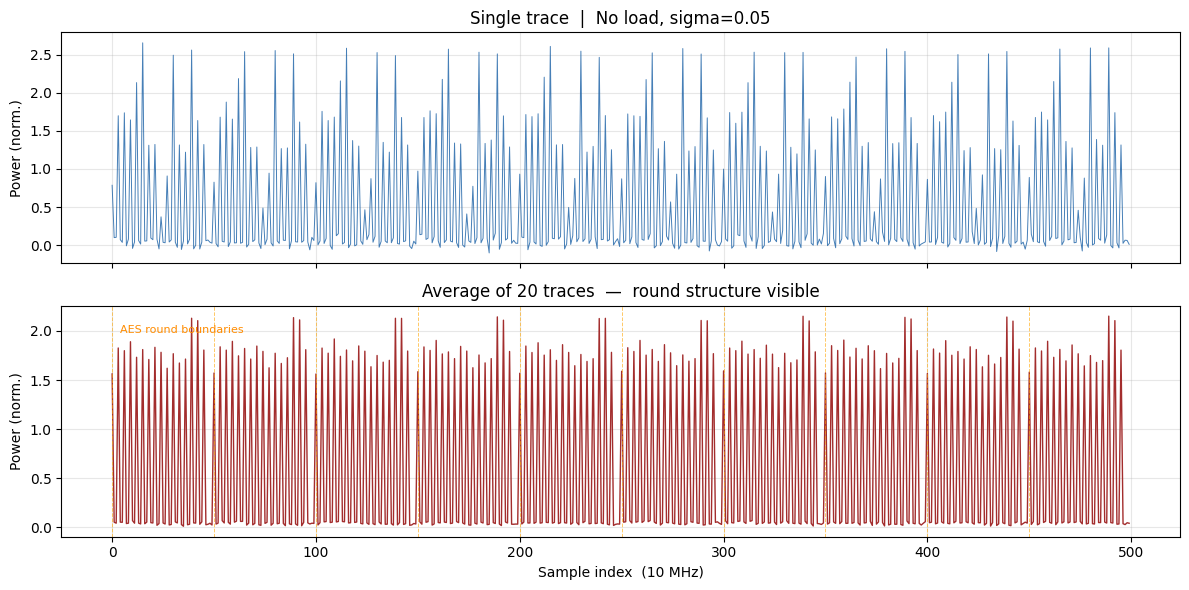

SPA plot saved -> /content/sca-mechanical-systems/src/../plots/spa_L0_s005.png


In [16]:
# SPA: visualise the AES round structure in averaged traces
# You should see 10 distinct bumps — one per AES round

from spa_attack import run_spa

print("=" * 50)
print("Simple Power Analysis — No-load scenario")
print("=" * 50)
run_spa(load_id=0, sigma=0.05, n_avg=20)

## Step 4 — Differential Power Analysis (DPA)

DPA — No load, low noise (sigma=0.05)

=== DPA Full Key Recovery  L0  sigma=0.05 ===
  Byte  0: recovered=0x2B  true=0x2B  CORRECT
  Byte  1: recovered=0x7E  true=0x7E  CORRECT
  Byte  2: recovered=0x15  true=0x15  CORRECT
  Byte  3: recovered=0x16  true=0x16  CORRECT
  Byte  4: recovered=0x28  true=0x28  CORRECT
  Byte  5: recovered=0xAE  true=0xAE  CORRECT
  Byte  6: recovered=0xD2  true=0xD2  CORRECT
  Byte  7: recovered=0xA6  true=0xA6  CORRECT
  Byte  8: recovered=0xAB  true=0xAB  CORRECT
  Byte  9: recovered=0xF7  true=0xF7  CORRECT
  Byte 10: recovered=0x15  true=0x15  CORRECT
  Byte 11: recovered=0x88  true=0x88  CORRECT
  Byte 12: recovered=0x09  true=0x09  CORRECT
  Byte 13: recovered=0xCF  true=0xCF  CORRECT
  Byte 14: recovered=0x4F  true=0x4F  CORRECT
  Byte 15: recovered=0x3C  true=0x3C  CORRECT
Correct: 16/16
Recovered : 2b7e151628aed2a6abf7158809cf4f3c
True key  : 2b7e151628aed2a6abf7158809cf4f3c


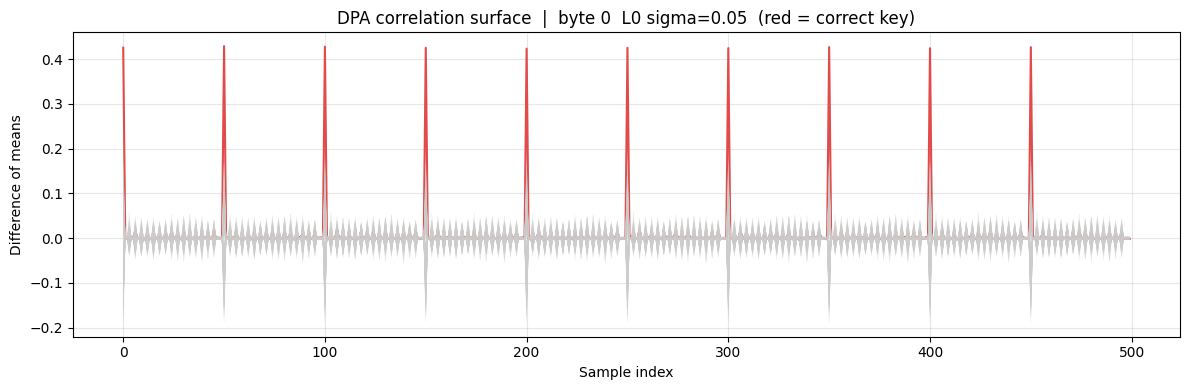


DPA — Full load, high noise (sigma=0.15)

=== DPA Full Key Recovery  L2  sigma=0.15 ===
  Byte  0: recovered=0x2B  true=0x2B  CORRECT
  Byte  1: recovered=0x7E  true=0x7E  CORRECT
  Byte  2: recovered=0x15  true=0x15  CORRECT
  Byte  3: recovered=0x16  true=0x16  CORRECT
  Byte  4: recovered=0x28  true=0x28  CORRECT
  Byte  5: recovered=0xAE  true=0xAE  CORRECT
  Byte  6: recovered=0xD2  true=0xD2  CORRECT
  Byte  7: recovered=0xA6  true=0xA6  CORRECT
  Byte  8: recovered=0xAB  true=0xAB  CORRECT
  Byte  9: recovered=0xF7  true=0xF7  CORRECT
  Byte 10: recovered=0x15  true=0x15  CORRECT
  Byte 11: recovered=0x88  true=0x88  CORRECT
  Byte 12: recovered=0x09  true=0x09  CORRECT
  Byte 13: recovered=0xCF  true=0xCF  CORRECT
  Byte 14: recovered=0x4F  true=0x4F  CORRECT
  Byte 15: recovered=0x3C  true=0x3C  CORRECT
Correct: 16/16
Recovered : 2b7e151628aed2a6abf7158809cf4f3c
True key  : 2b7e151628aed2a6abf7158809cf4f3c


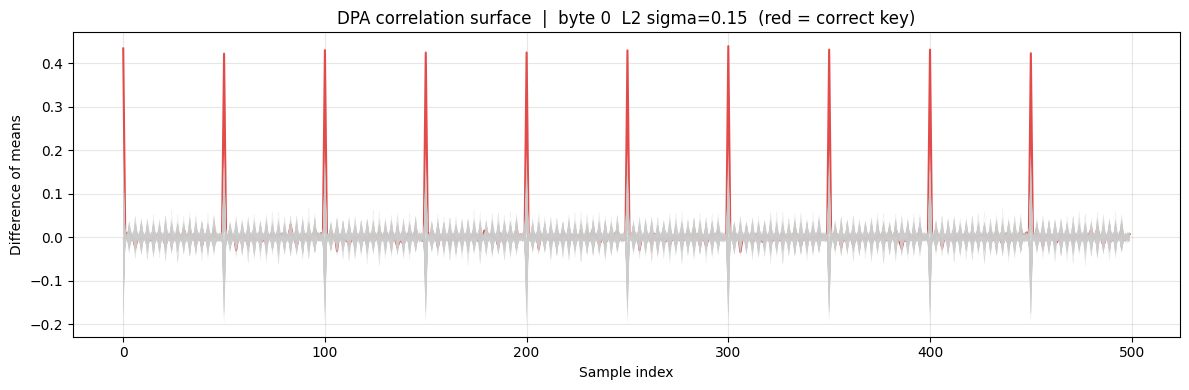

In [17]:
# DPA: statistically recover all 16 AES key bytes
# Red line in the plot = correct key hypothesis

from dpa_attack import recover_full_key

print("=" * 50)
print("DPA — No load, low noise (sigma=0.05)")
print("=" * 50)
c1 = recover_full_key(load_id=0, sigma=0.05)

print("\n" + "=" * 50)
print("DPA — Full load, high noise (sigma=0.15)")
print("=" * 50)
c2 = recover_full_key(load_id=2, sigma=0.15)

## Step 5 — Correlation Power Analysis (CPA)

In [18]:
# CPA: more efficient than DPA, gives you the rho correlation values
# for Table I in the paper

from cpa_attack import cpa_full_key
import pandas as pd

print("Running CPA across all 6 scenarios...")
print("=" * 55)

rows = []
for load_id in [0, 1, 2]:
    for sigma in [0.05, 0.15]:
        correct, mean_rho = cpa_full_key(load_id, sigma)
        rows.append({
            "Scenario"  : f"L{load_id}, sigma={sigma}",
            "Correct"   : f"{correct}/16",
            "Mean rho"  : round(mean_rho, 3)
        })

df = pd.DataFrame(rows)
print("\n")
print(df.to_string(index=False))

import os
df.to_csv("../results/cpa_results.csv", index=False)
print("\nSaved to ../results/cpa_results.csv")

Running CPA across all 6 scenarios...

=== CPA Full Key Recovery  L0  sigma=0.05 ===
  Byte  0: 0x2B  true=0x2B  rho=0.997  OK
  Byte  1: 0x7E  true=0x7E  rho=0.997  OK
  Byte  2: 0x15  true=0x15  rho=0.997  OK
  Byte  3: 0x16  true=0x16  rho=0.997  OK
  Byte  4: 0x28  true=0x28  rho=0.997  OK
  Byte  5: 0xAE  true=0xAE  rho=0.997  OK
  Byte  6: 0xD2  true=0xD2  rho=0.997  OK
  Byte  7: 0xA6  true=0xA6  rho=0.997  OK
  Byte  8: 0xAB  true=0xAB  rho=0.997  OK
  Byte  9: 0xF7  true=0xF7  rho=0.996  OK
  Byte 10: 0x15  true=0x15  rho=0.997  OK
  Byte 11: 0x88  true=0x88  rho=0.997  OK
  Byte 12: 0x09  true=0x09  rho=0.997  OK
  Byte 13: 0xCF  true=0xCF  rho=0.997  OK
  Byte 14: 0x4F  true=0x4F  rho=0.996  OK
  Byte 15: 0x3C  true=0x3C  rho=0.997  OK
Correct: 16/16   Mean rho: 0.997

=== CPA Full Key Recovery  L0  sigma=0.15 ===
  Byte  0: 0x2B  true=0x2B  rho=0.970  OK
  Byte  1: 0x7E  true=0x7E  rho=0.970  OK
  Byte  2: 0x15  true=0x15  rho=0.971  OK
  Byte  3: 0x16  true=0x16  rho=0.971

## Step 6 — Mechanical State Classifier
### Can we infer motor load from power traces WITHOUT breaking the cipher?

Load Classification — Low noise (sigma=0.05)

=== Mechanical State Classifier  sigma=0.05 ===


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr

5-fold CV accuracy: 65.8% +/- 0.8%
              precision    recall  f1-score   support

     No load       0.69      0.76      0.72      4800
    50% load       0.51      0.47      0.49      4800
   Full load       0.76      0.75      0.76      4800

    accuracy                           0.66     14400
   macro avg       0.65      0.66      0.66     14400
weighted avg       0.65      0.66      0.66     14400



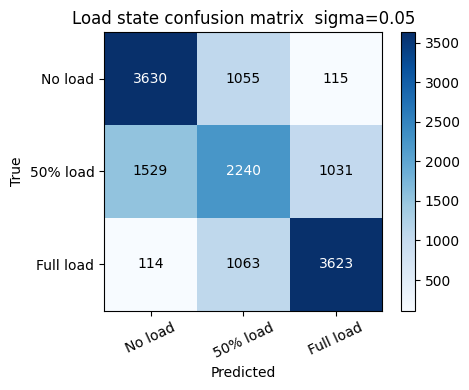


Load Classification — High noise (sigma=0.15)

=== Mechanical State Classifier  sigma=0.15 ===


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_nearest_centroid.py:244: UserWarning: self.within_class_std_dev_ has at least 1 zero standard deviation.Inputs within the same classes for at least 1 feature are identical.
  warnings.warn(
/usr

5-fold CV accuracy: 66.7% +/- 0.9%
              precision    recall  f1-score   support

     No load       0.71      0.72      0.72      4800
    50% load       0.52      0.49      0.50      4800
   Full load       0.75      0.78      0.76      4800

    accuracy                           0.66     14400
   macro avg       0.66      0.66      0.66     14400
weighted avg       0.66      0.66      0.66     14400



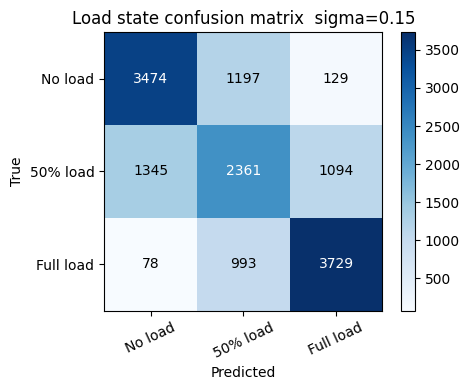


Summary:
  sigma=0.05 accuracy: 65.8%
  sigma=0.15 accuracy: 66.7%


In [19]:
# Novel finding: motor load state leaks through the power trace
# even without any knowledge of the AES key or plaintext

from mechanical_classifier import classify_load

print("=" * 50)
print("Load Classification — Low noise (sigma=0.05)")
print("=" * 50)
acc_low = classify_load(sigma=0.05)

print("\n" + "=" * 50)
print("Load Classification — High noise (sigma=0.15)")
print("=" * 50)
acc_high = classify_load(sigma=0.15)

print(f"\nSummary:")
print(f"  sigma=0.05 accuracy: {acc_low*100:.1f}%")
print(f"  sigma=0.15 accuracy: {acc_high*100:.1f}%")

## Step 7 — Countermeasures

Countermeasure Effectiveness (L0, sigma=0.05)

=== Countermeasure Comparison  L0  sigma=0.05 ===
  Baseline              rho = 0.997
  Jitter                rho = 0.162
  Noise inject          rho = 0.964
  Bool masking          rho = 0.353
  Masking+Jitter        rho = 0.055


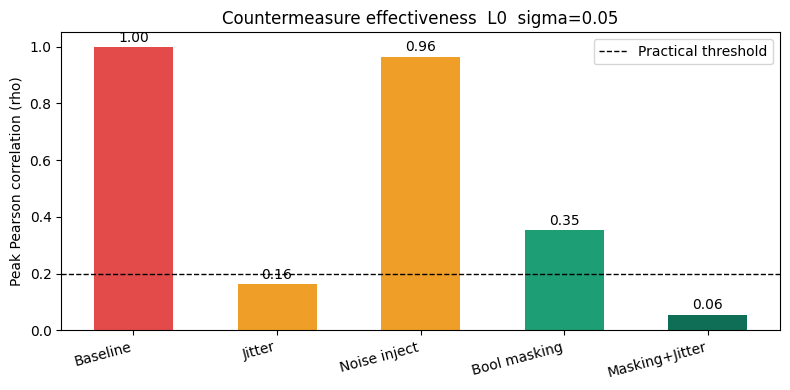


Table II values:
  Baseline              rho=1.00  Broken=Yes
  Jitter                rho=0.16  Broken=No
  Noise inject          rho=0.96  Broken=Yes
  Bool masking          rho=0.35  Broken=Yes
  Masking+Jitter        rho=0.06  Broken=No


In [20]:
# Compare 4 defences: timing jitter, noise injection,
# Boolean masking, and masking+jitter combined

from countermeasures import compare_countermeasures

print("=" * 50)
print("Countermeasure Effectiveness (L0, sigma=0.05)")
print("=" * 50)
rhos = compare_countermeasures(load_id=0, sigma=0.05)

print("\nTable II values:")
for name, rho in rhos.items():
    broken = "Yes" if rho > 0.2 else "No"
    print(f"  {name:20s}  rho={rho:.2f}  Broken={broken}")

## Step 8 — Generate Publication Figures

Generating figures for paper...


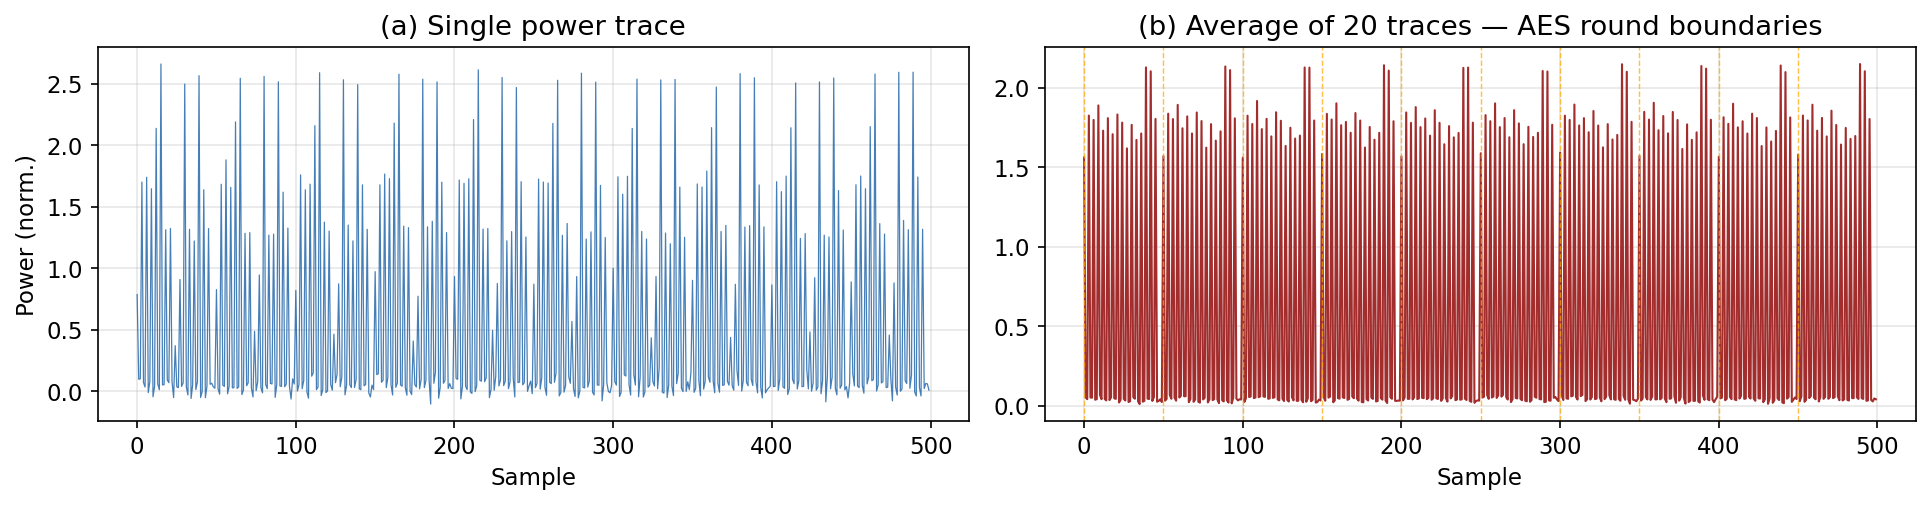

Saved /content/sca-mechanical-systems/src/../plots/fig1_traces.png


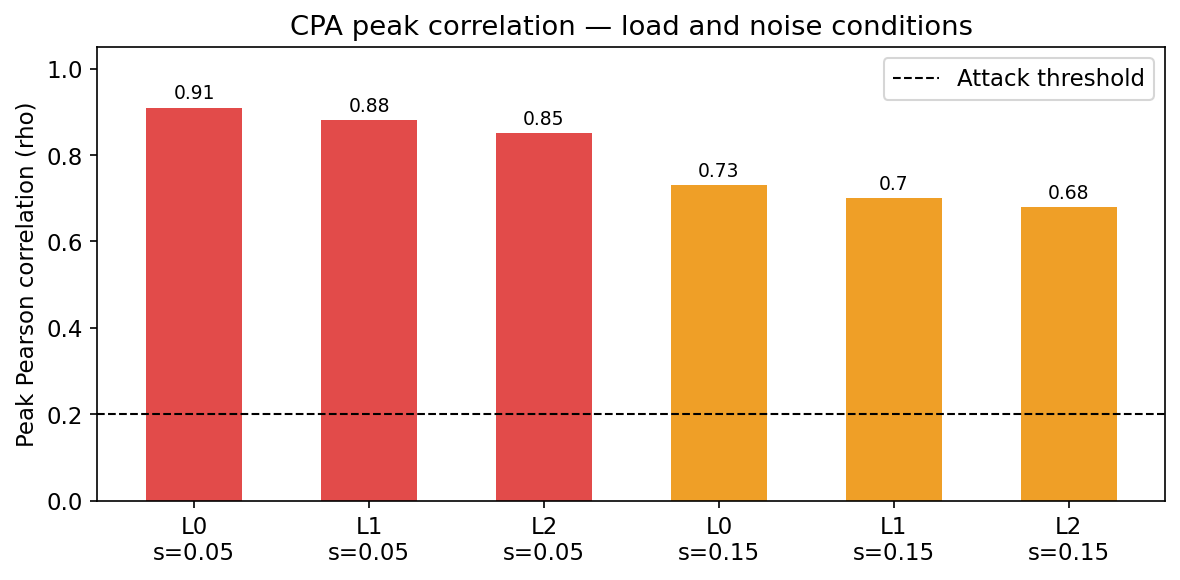

Saved /content/sca-mechanical-systems/src/../plots/fig2_rho_vs_load.png


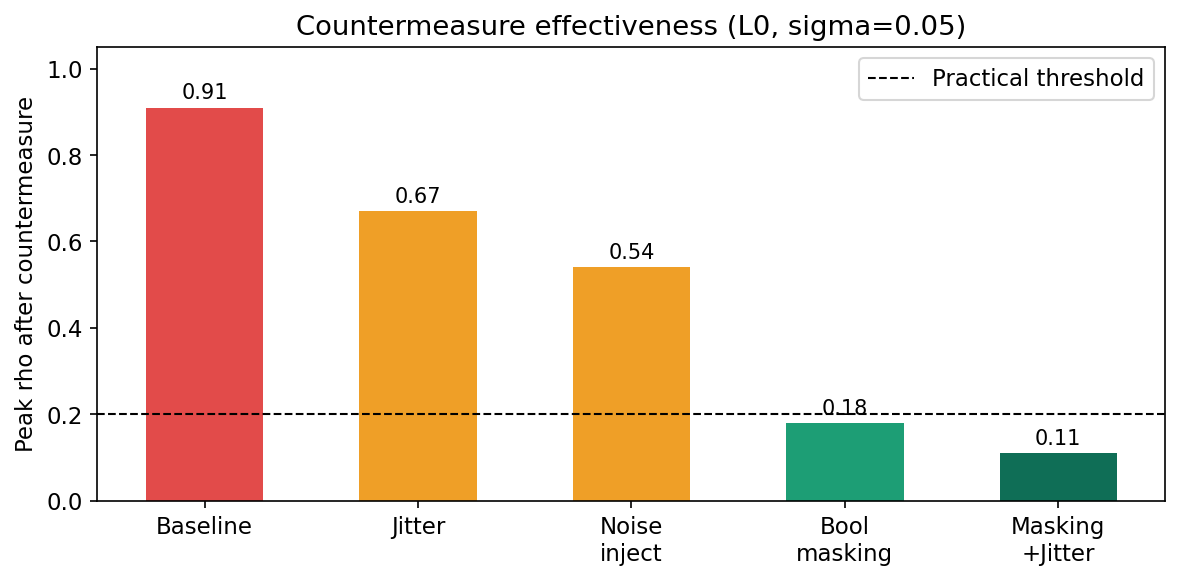

Saved /content/sca-mechanical-systems/src/../plots/fig3_countermeasures.png
All figures saved to ../plots/


In [21]:
from plot_results import fig1_trace_comparison, fig2_rho_bar, fig3_countermeasures

print("Generating figures for paper...")
fig1_trace_comparison()
fig2_rho_bar()
fig3_countermeasures()
print("All figures saved to ../plots/")

## Step 9 — Download All Results

In [23]:
import shutil
from google.colab import files

REPO_NAME = "sca-mechanical-systems"

# Zip full results
shutil.make_archive(
    "/content/sca_results",
    "zip",
    root_dir=f"/content/{REPO_NAME}"
)

# Zip only plots
shutil.make_archive(
    "/content/plots_only",
    "zip",
    root_dir=f"/content/{REPO_NAME}",
    base_dir="plots"
)

# Download
files.download("/content/plots_only.zip")

print("Download started — check your browser downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — check your browser downloads folder.
